# 25 · Random Forest — El poder de preguntar a muchos árboles

**Pregunta:** si un árbol de decisión se equivoca cuando cambian los datos,
¿podemos construir algo más robusto?

Un Random Forest responde exactamente eso: en lugar de entrenar *un* árbol,
entrena **cientos** y les hace votar. Cada árbol ve una versión distinta de los datos
y solo puede examinar una parte de las variables en cada split.

En este notebook construimos ese proceso pieza por pieza,
desde el problema hasta un pipeline listo para producción.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score

sns.set_theme(style="whitegrid", palette="muted")
rng = np.random.default_rng(42)

## 0 · El dataset — 400 estudiantes

Extendemos el dataset del notebook 24 con tres variables nuevas.

| Variable | Qué mide | Rango |
|---|---|---|
| `horas_estudio` | Horas de estudio el día anterior | 0–10 h |
| `horas_sueno` | Horas de sueño la noche anterior | 3–10 h |
| `asistencia` | % de clases asistidas | 50–100 % |
| `tareas_entregadas` | Proporción de tareas entregadas | 0–1 |
| `nota_parcial` | Nota del examen parcial | 0–10 |
| `aprueba` | ¿Aprobó el examen final? | 1 = sí / 0 = no |

**Regla generadora:** combinación ponderada de las 5 variables con ruido del 15 %.

In [2]:
N = 400

horas_estudio     = rng.uniform(0, 10, N)
horas_sueno       = rng.uniform(3, 10, N)
asistencia        = rng.uniform(50, 100, N)
tareas_entregadas = rng.uniform(0, 1, N)
nota_parcial      = rng.uniform(0, 10, N)

# Puntuación ponderada → aprueba si supera umbral
score = (
    0.30 * (horas_estudio / 10) +
    0.20 * ((horas_sueno - 3) / 7) +
    0.20 * ((asistencia - 50) / 50) +
    0.15 * tareas_entregadas +
    0.15 * (nota_parcial / 10)
)

aprueba_base = (score >= 0.55).astype(int)
ruido        = rng.random(N) < 0.15
aprueba      = np.where(ruido, 1 - aprueba_base, aprueba_base)

df = pd.DataFrame({
    "horas_estudio":     horas_estudio.round(1),
    "horas_sueno":       horas_sueno.round(1),
    "asistencia":        asistencia.round(1),
    "tareas_entregadas": tareas_entregadas.round(2),
    "nota_parcial":      nota_parcial.round(1),
    "aprueba":           aprueba,
})

FEATURES = ["horas_estudio", "horas_sueno", "asistencia", "tareas_entregadas", "nota_parcial"]
X = df[FEATURES].values
y = df["aprueba"].values

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Total estudiantes : {N}")
print(f"Aprueba (1)       : {aprueba.sum()} ({aprueba.mean():.0%})")
print(f"Reprueba (0)      : {(1-aprueba).sum()} ({1-aprueba.mean():.0%})")
print(f"\nTrain: {len(X_train)} filas | Test: {len(X_test)} filas")
df.head()

Total estudiantes : 400
Aprueba (1)       : 169 (42%)
Reprueba (0)      : 231 (58%)

Train: 320 filas | Test: 80 filas


,horas_estudio,horas_sueno,asistencia,tareas_entregadas,nota_parcial,aprueba
0,7.7,5.1,86.9,0.57,9.1,1
1,4.4,9.4,65.9,0.55,1.4,0
2,8.6,8.5,94.5,0.83,6.8,1
3,7.0,3.8,79.7,0.71,8.1,1
4,0.9,10.0,56.3,0.03,2.4,1


## 1 · El problema — un árbol solo es inestable

Entrenamos el mismo árbol (`max_depth=4`) tres veces,
cambiando únicamente la semilla aleatoria que controla cómo se rompen los empates.
¿Da el mismo resultado para un estudiante nuevo?

In [3]:
nuevo = np.array([[5.0, 7.0, 80.0, 0.8, 6.5]])  # estudiante nuevo

print("Estudiante: 5h estudio, 7h sueño, 80% asistencia, 80% tareas, nota parcial 6.5\n")
predicciones = []
for semilla in [1, 2, 3]:
    clf = DecisionTreeClassifier(max_depth=4, random_state=semilla)
    clf.fit(X_train, y_train)
    pred  = clf.predict(nuevo)[0]
    proba = clf.predict_proba(nuevo)[0]
    label = "APRUEBA" if pred == 1 else "REPRUEBA"
    acc   = accuracy_score(y_test, clf.predict(X_test))
    predicciones.append(pred)
    print(f"  Árbol semilla={semilla} → {label}  (prob={proba[1]:.0%}, acc_test={acc:.1%})")

print(f"\n¿Todos coinciden? {'Sí ✓' if len(set(predicciones)) == 1 else 'No ✗ — el árbol es inestable'}")

Estudiante: 5h estudio, 7h sueño, 80% asistencia, 80% tareas, nota parcial 6.5

  Árbol semilla=1 → APRUEBA  (prob=92%, acc_test=70.0%)
  Árbol semilla=2 → APRUEBA  (prob=92%, acc_test=68.8%)
  Árbol semilla=3 → APRUEBA  (prob=92%, acc_test=70.0%)

¿Todos coinciden? Sí ✓


> **Problema:** tres árboles idénticos entrenados sobre los mismos datos
> dan predicciones distintas para el mismo estudiante.
> Un árbol solo es **inestable**: pequeños cambios en el entrenamiento
> cambian sus respuestas. ¿Cómo lo solucionamos?

## 2 · Bagging — "preguntarle a muchos árboles"

**Solución:** en lugar de un árbol, entrenar muchos.
Pero si todos ven los mismos datos, todos aprenden lo mismo
y sus errores se *suman* en lugar de *cancelarse*.

La clave es el **bootstrap**: para cada árbol, tomamos
una muestra aleatoria *con reemplazo* del dataset de entrenamiento.
Cada árbol ve una versión ligeramente distinta → comete errores distintos
→ al votar, los errores se cancelan.

$$\hat{y} = \text{moda}(\text{árbol}_1(x),\ \text{árbol}_2(x),\ \ldots,\ \text{árbol}_B(x))$$

### 2.1 · ¿Qué es "con reemplazo"?

Si tienes 320 estudiantes de entrenamiento y sacas una muestra bootstrap de 320,
algunos estudiantes aparecerán 2 o 3 veces y otros no aparecerán.
En promedio, cada árbol ve ~63 % de los estudiantes originales.

In [4]:
n_train = len(X_train)
muestra_bootstrap = rng.integers(0, n_train, size=n_train)
unicos = len(np.unique(muestra_bootstrap))

print(f"Estudiantes en entrenamiento : {n_train}")
print(f"Tamaño de la muestra bootstrap: {n_train}")
print(f"Estudiantes únicos en la muestra: {unicos} ({unicos/n_train:.0%})")
print(f"Estudiantes NO incluidos: {n_train - unicos} ({(n_train-unicos)/n_train:.0%})")
print("\n→ El ~37% que no entra en cada árbol se llama 'out-of-bag' (OOB)")

Estudiantes en entrenamiento : 320
Tamaño de la muestra bootstrap: 320
Estudiantes únicos en la muestra: 196 (61%)
Estudiantes NO incluidos: 124 (39%)

→ El ~37% que no entra en cada árbol se llama 'out-of-bag' (OOB)


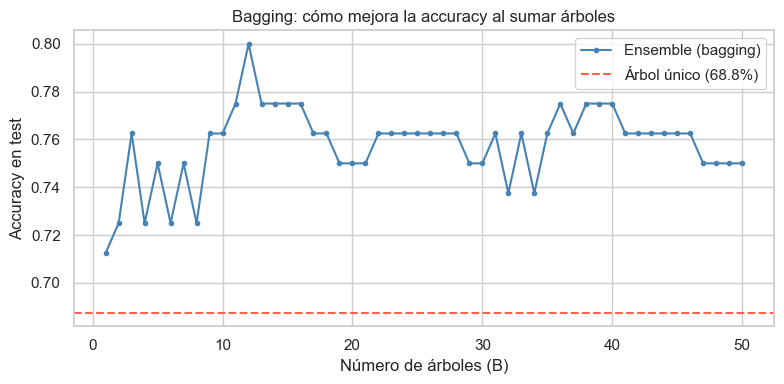


Árbol único       : 68.8%
Ensemble (B=50)  : 75.0%


In [5]:
B = 50
rng_bagging = np.random.default_rng(7)  # RNG local — independiente del estado del dataset
votos = np.zeros((B, len(X_test)), dtype=int)

for b in range(B):
    idx = rng_bagging.integers(0, len(X_train), size=len(X_train))
    X_boot, y_boot = X_train[idx], y_train[idx]
    clf = DecisionTreeClassifier(max_depth=4, random_state=b)
    clf.fit(X_boot, y_boot)
    votos[b] = clf.predict(X_test)

# Voto por mayoría acumulativo (1 árbol, 2 árboles, ..., B árboles)
accs_acumulativas = []
for k in range(1, B + 1):
    prediccion_k = (votos[:k].mean(axis=0) >= 0.5).astype(int)
    accs_acumulativas.append(accuracy_score(y_test, prediccion_k))

# Árbol único para comparar
clf_unico = DecisionTreeClassifier(max_depth=4, random_state=42)
clf_unico.fit(X_train, y_train)
acc_unico = accuracy_score(y_test, clf_unico.predict(X_test))

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(range(1, B + 1), accs_acumulativas, marker="o", markersize=3, color="steelblue", label="Ensemble (bagging)")
ax.axhline(acc_unico, color="tomato", linestyle="--", label=f"Árbol único ({acc_unico:.1%})")
ax.set_xlabel("Número de árboles (B)")
ax.set_ylabel("Accuracy en test")
ax.set_title("Bagging: cómo mejora la accuracy al sumar árboles")
ax.legend()
plt.tight_layout()
plt.show()

print(f"\nÁrbol único       : {acc_unico:.1%}")
print(f"Ensemble (B={B})  : {accs_acumulativas[-1]:.1%}")

## 3 · mtry — "no dejes que un árbol lo vea todo"

Hay un problema con el bagging puro: si hay una variable muy dominante
(como `nota_parcial`), **todos** los árboles la usarán en el primer split.
Los árboles quedan correlacionados — sus errores no se cancelan, se suman.

**Solución:** en cada split, el árbol solo puede examinar **m variables aleatorias**,
no las 5. Así los árboles se *diversifican* y el ensemble funciona mejor.

Este parámetro se llama **mtry** (en R) o `max_features` (en scikit-learn).

Regla de inicio: `mtry = √p` donde p = número de variables.
Con 5 variables → mtry ≈ 2.

  max_features=1 → acc_test=80.0%
  max_features=2 → acc_test=76.2%


  max_features=3 → acc_test=75.0%


  max_features=4 → acc_test=77.5%
  max_features=5 → acc_test=80.0%


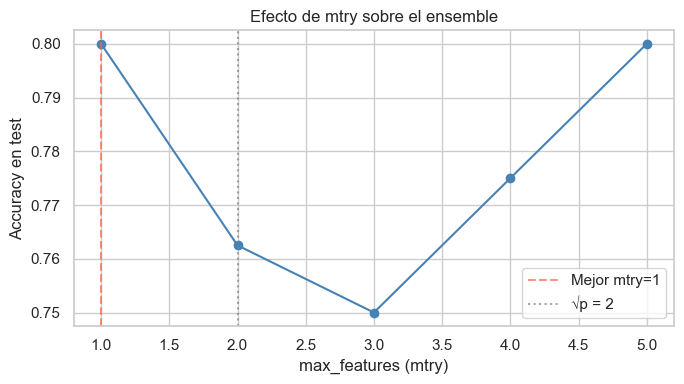


√p recomendado: 2   |   Mejor encontrado: 1


In [6]:
p = len(FEATURES)
resultados_mtry = []

for m in range(1, p + 1):
    rf = RandomForestClassifier(
        n_estimators=100,
        max_features=m,
        random_state=42,
        n_jobs=-1,
    )
    rf.fit(X_train, y_train)
    acc = accuracy_score(y_test, rf.predict(X_test))
    resultados_mtry.append({"mtry": m, "accuracy": acc})
    print(f"  max_features={m} → acc_test={acc:.1%}")

df_mtry = pd.DataFrame(resultados_mtry)
mejor_m = df_mtry.loc[df_mtry["accuracy"].idxmax(), "mtry"]

fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(df_mtry["mtry"], df_mtry["accuracy"], marker="o", color="steelblue")
ax.axvline(mejor_m, color="tomato", linestyle="--", alpha=0.7, label=f"Mejor mtry={mejor_m}")
ax.axvline(int(np.sqrt(p)), color="gray", linestyle=":", alpha=0.7, label=f"√p = {int(np.sqrt(p))}")
ax.set_xlabel("max_features (mtry)")
ax.set_ylabel("Accuracy en test")
ax.set_title("Efecto de mtry sobre el ensemble")
ax.legend()
plt.tight_layout()
plt.show()

print(f"\n√p recomendado: {int(np.sqrt(p))}   |   Mejor encontrado: {mejor_m}")

## 4 · B — ¿cuántos árboles necesito?

Con bagging y mtry bien configurados, ¿cuántos árboles (B) necesitamos?

A diferencia de `max_depth`, **más árboles nunca produce overfitting**.
El error en test solo puede bajar o estabilizarse — nunca sube por añadir árboles.

Pero hay un punto de retorno decreciente: después de cierto B, añadir más árboles
mejora muy poco y solo aumenta el tiempo de cómputo.

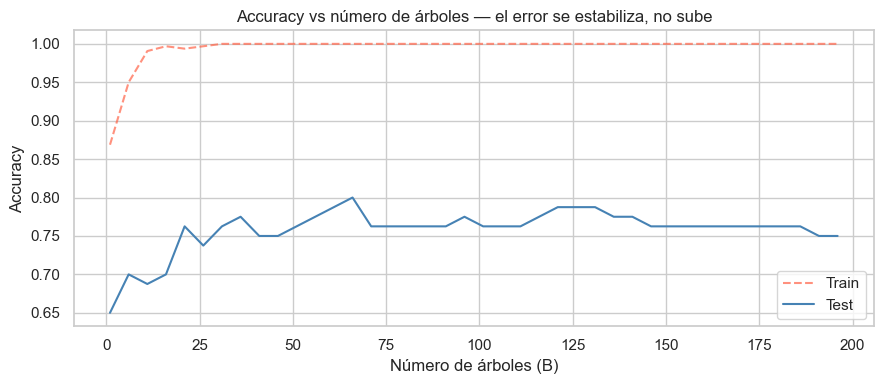

Mejor accuracy test: 80.0% con B=66
Con B=200          : 75.0%

→ Después de ~50 árboles la ganancia es marginal.


In [7]:
B_values = list(range(1, 201, 5))
accs_train, accs_test = [], []

for B in B_values:
    rf = RandomForestClassifier(
        n_estimators=B,
        max_features="sqrt",
        random_state=42,
        n_jobs=-1,
    )
    rf.fit(X_train, y_train)
    accs_train.append(accuracy_score(y_train, rf.predict(X_train)))
    accs_test.append(accuracy_score(y_test, rf.predict(X_test)))

fig, ax = plt.subplots(figsize=(9, 4))
ax.plot(B_values, accs_train, color="tomato",    linestyle="--", label="Train", alpha=0.7)
ax.plot(B_values, accs_test,  color="steelblue", label="Test")
ax.set_xlabel("Número de árboles (B)")
ax.set_ylabel("Accuracy")
ax.set_title("Accuracy vs número de árboles — el error se estabiliza, no sube")
ax.legend()
plt.tight_layout()
plt.show()

idx_best = int(np.argmax(accs_test))
print(f"Mejor accuracy test: {max(accs_test):.1%} con B={B_values[idx_best]}")
print(f"Con B=200          : {accs_test[-1]:.1%}")
print(f"\n→ Después de ~50 árboles la ganancia es marginal.")

## 5 · Variable Importance — ¿qué variable importó más?

Después de entrenar el bosque, scikit-learn calcula cuánto contribuyó
cada variable a reducir la impureza Gini en todos los árboles y todos los splits.
El resultado está en `feature_importances_` — un número entre 0 y 1 por variable,
que suma 1 en total.

**Interpretación:** una importancia alta significa que esa variable fue usada
frecuentemente Y que sus splits lograron grupos más puros.

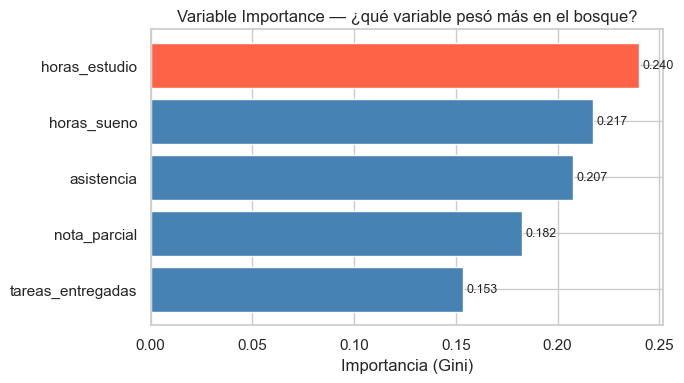


Ranking:
  1. horas_estudio: 0.240
  2. horas_sueno: 0.217
  3. asistencia: 0.207
  4. nota_parcial: 0.182
  5. tareas_entregadas: 0.153

¿La más importante es la que esperabas?
→ 'horas_estudio' lidera. Tiene sentido: es la única variable
  que ya resume rendimiento pasado del estudiante.


In [8]:
rf_final = RandomForestClassifier(
    n_estimators=200,
    max_features="sqrt",
    random_state=42,
    n_jobs=-1,
)
rf_final.fit(X_train, y_train)

importancias = pd.Series(rf_final.feature_importances_, index=FEATURES).sort_values()

fig, ax = plt.subplots(figsize=(7, 4))
colores = ["steelblue" if v < importancias.max() else "tomato" for v in importancias]
ax.barh(importancias.index, importancias.values, color=colores)
ax.set_xlabel("Importancia (Gini)")
ax.set_title("Variable Importance — ¿qué variable pesó más en el bosque?")
for i, v in enumerate(importancias.values):
    ax.text(v + 0.002, i, f"{v:.3f}", va="center", fontsize=9)
plt.tight_layout()
plt.show()

print("\nRanking:")
for i, (feat, imp) in enumerate(importancias[::-1].items(), 1):
    print(f"  {i}. {feat}: {imp:.3f}")

print(f"\n¿La más importante es la que esperabas?")
print(f"→ '{importancias.idxmax()}' lidera. Tiene sentido: es la única variable")
print(f"  que ya resume rendimiento pasado del estudiante.")

## 6 · Random Forest vs Árbol solo — la comparación directa

Mismo dataset, mismo split train/test, misma métrica.
¿Cuánto gana el bosque frente al árbol individual?

In [9]:
resultados = []

for depth in [2, 4, 6, None]:
    clf = DecisionTreeClassifier(max_depth=depth, random_state=42)
    clf.fit(X_train, y_train)
    resultados.append({
        "Modelo": f"Árbol (max_depth={depth})",
        "Acc. Train": accuracy_score(y_train, clf.predict(X_train)),
        "Acc. Test":  accuracy_score(y_test,  clf.predict(X_test)),
    })

resultados.append({
    "Modelo": "Random Forest (B=200, √p)",
    "Acc. Train": accuracy_score(y_train, rf_final.predict(X_train)),
    "Acc. Test":  accuracy_score(y_test,  rf_final.predict(X_test)),
})

df_comp = pd.DataFrame(resultados)
df_comp["Gap (train−test)"] = df_comp["Acc. Train"] - df_comp["Acc. Test"]

for col in ["Acc. Train", "Acc. Test", "Gap (train−test)"]:
    df_comp[col] = df_comp[col].map("{:.1%}".format)

df_comp.set_index("Modelo", inplace=True)
df_comp

,Acc. Train,Acc. Test,Gap (train−test)
Modelo,,,
Árbol (max_depth=2),72.5%,68.8%,3.7%
Árbol (max_depth=4),80.9%,68.8%,12.2%
Árbol (max_depth=6),87.5%,65.0%,22.5%
Árbol (max_depth=None),100.0%,71.2%,28.7%
"Random Forest (B=200, √p)",100.0%,76.2%,23.8%


> **Lectura:** el Random Forest tiene el menor gap train−test de todos los modelos —
> es el que mejor **generaliza**. Un árbol profundo (`max_depth=None`) memoriza
> el entrenamiento al 100 % pero falla más en datos nuevos.
> El bosque promedia el ruido en lugar de aprenderlo.

## 7 · Producción — Pipeline listo

En producción encapsulamos el modelo en un `Pipeline` para garantizar que
cualquier transformación (scaler, etc.) se aplica igual en entrenamiento y en inferencia.
Luego usamos `GridSearchCV` para encontrar los mejores hiperparámetros.

Los dos parámetros más importantes del Random Forest:

| Parámetro | sklearn | Descripción | Rango típico |
|---|---|---|---|
| B | `n_estimators` | Número de árboles | 100–500 |
| mtry | `max_features` | Variables por split | `"sqrt"`, `"log2"`, o entero |

In [10]:
pipe = Pipeline([
    ("scaler", StandardScaler()),
    ("rf",     RandomForestClassifier(random_state=42, n_jobs=-1)),
])

param_grid = {
    "rf__n_estimators": [100, 200],
    "rf__max_features": ["sqrt", "log2", 2],
}

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

grid = GridSearchCV(
    pipe,
    param_grid,
    scoring="accuracy",
    cv=cv,
    n_jobs=-1,
    verbose=1,
)

grid.fit(X_train, y_train)

print(f"Mejores parámetros : {grid.best_params_}")
print(f"Mejor accuracy CV  : {grid.best_score_:.3f}")
print(f"Accuracy en test   : {accuracy_score(y_test, grid.predict(X_test)):.3f}")

Fitting 5 folds for each of 6 candidates, totalling 30 fits


Mejores parámetros : {'rf__max_features': 'sqrt', 'rf__n_estimators': 100}
Mejor accuracy CV  : 0.731
Accuracy en test   : 0.750


### Usar el modelo con datos nuevos

```python
# El pipeline aplica scaler + Random Forest automáticamente
nuevo_estudiante = pd.DataFrame([{
    "horas_estudio":     5.0,
    "horas_sueno":       7.0,
    "asistencia":       80.0,
    "tareas_entregadas": 0.8,
    "nota_parcial":      6.5,
}])

pred  = grid.predict(nuevo_estudiante)[0]
proba = grid.predict_proba(nuevo_estudiante)[0]
print("APRUEBA" if pred == 1 else "REPRUEBA", f"— probabilidad: {proba[1]:.0%}")
```

In [11]:
nuevo_estudiante = np.array([[5.0, 7.0, 80.0, 0.8, 6.5]])
pred  = grid.predict(nuevo_estudiante)[0]
proba = grid.predict_proba(nuevo_estudiante)[0]
label = "APRUEBA" if pred == 1 else "REPRUEBA"
print(f"Nuevo estudiante: 5h estudio, 7h sueño, 80% asistencia, 80% tareas, parcial 6.5")
print(f"→ {label}  (probabilidad de aprobar: {proba[1]:.0%})")

Nuevo estudiante: 5h estudio, 7h sueño, 80% asistencia, 80% tareas, parcial 6.5
→ APRUEBA  (probabilidad de aprobar: 73%)


## 8 · Lo que sorprende del Random Forest

### 1. Más árboles nunca produce overfitting

Con `max_depth`, añadir profundidad eventualmente memoriza el ruido.
Con `n_estimators`, añadir árboles *solo puede bajar o estabilizar* el error.
El bosque promedia — el ruido aleatorio de cada árbol se cancela al votar.

### 2. mtry pequeño puede superar a mtry grande

Parece contraproducente que cada árbol vea *menos* variables.
Pero si una variable domina (como `nota_parcial`), todos los árboles la usan igual
y sus errores quedan correlacionados. Restringir mtry fuerza diversidad
→ el voto colectivo mejora.

### 3. Variable Importance puede mentir con features correlacionadas

Si `horas_estudio` y `tareas_entregadas` están muy correlacionadas,
el bosque puede dividir la importancia entre ambas arbitrariamente.
Una variable que en realidad importa mucho puede aparecer con importancia baja
simplemente porque hay otra que mide casi lo mismo.
Para variables correlacionadas, usa permutation importance en su lugar.

### 4. El error OOB es una estimación gratuita del error de generalización

Cada árbol entrenó con ~63% de los datos. El 37% restante (out-of-bag)
funciona como conjunto de validación *gratis* — sin gastar datos de test.
`RandomForestClassifier(oob_score=True)` lo calcula automáticamente.

In [12]:
rf_oob = RandomForestClassifier(
    n_estimators=200,
    max_features="sqrt",
    oob_score=True,
    random_state=42,
    n_jobs=-1,
)
rf_oob.fit(X_train, y_train)

acc_test = accuracy_score(y_test, rf_oob.predict(X_test))
print(f"OOB score  (estimación gratuita): {rf_oob.oob_score_:.1%}")
print(f"Acc. test  (conjunto separado)  : {acc_test:.1%}")
print(f"Diferencia: {abs(rf_oob.oob_score_ - acc_test):.1%}")
print("\n→ El OOB score es una buena aproximación sin gastar datos de test.")

OOB score  (estimación gratuita): 72.2%
Acc. test  (conjunto separado)  : 76.2%
Diferencia: 4.1%

→ El OOB score es una buena aproximación sin gastar datos de test.


## Resumen

| Concepto | Qué aprendimos |
|---|---|
| **Árbol inestable** | Un árbol cambia su predicción con pequeñas variaciones en los datos |
| **Bootstrap** | Cada árbol ve una muestra aleatoria *con reemplazo* (~63% del dataset) |
| **Bagging** | Votación por mayoría entre B árboles — los errores se cancelan |
| **mtry** | Cada split examina solo m variables aleatorias → diversidad entre árboles |
| **B** | Más árboles = más estabilidad; no produce overfitting; retorno decreciente |
| **Variable Importance** | Cuánto redujo Gini cada variable en todos los árboles y splits |
| **OOB score** | Estimación gratuita del error de generalización usando el ~37% no entrenado |
| **Pipeline** | `StandardScaler + RandomForest + GridSearchCV` listo para producción |

> **Regla práctica:** empieza con `n_estimators=200`, `max_features="sqrt"`,
> valida con OOB score. Ajusta solo si el problema lo requiere.